##MOBILITY ECONOMY PROJECT

##🧩 Step 1: Load and Explore
Before cleaning or combining the data, it is necessary to familiarize yourself with the structure of both datasets.
In this stage, you will validate that the files load correctly, learn about their columns and data types, and detect potential inconsistencies.

### 1.1 Data Loading and Quick View

**🎯Objective:**
Import the necessary libraries, load the CSV files into DataFrames, and perform a preliminary review to understand their content.

**Key Actions:**
- Import the `pandas`, `numpy`, `seaborn` and `matplotlib.pyplot` libraries.
- Load the files using `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Save the DataFrames in the variables `traffic` and `eco`.
- Display the first 5 rows of each DataFrame.


In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
# Load the files
traffic = pd.read_csv('/content/drive/MyDrive/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/content/drive/MyDrive/datasets/oecd_city_economy.csv')

In [72]:
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [73]:
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Step 2: Explore, Clean, and Prepare the Data


### 2.1 Explore Structure and Data Types

**🎯Objective:**
Identify columns with incorrect types, distribution, and nulls; note the columns requiring conversion.

**Key Actions:**

- Use .info() to understand the structure of both DataFrames.

- Display the first 3 rows of each DF.

- Identify if the details of each DF are correct or if they require corrections.

In [74]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In the structure of the traffic DF, it is observed that:

- The `UpdateTimeUTC` and `UpdateTimeUTC` columns are of type `object` and should be `datetime64`.

- The `JamsCount` column is of type `float64` and should be `int64`.

In [75]:
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


In the structure of the eco DF, it is observed that:

- The `City GDP/capita` and `Unemployment %` columns are of type `object` and should be `float64`.

- The `PM2.5 (μg/m³)` and `Population (M)` columns are of type `object` and should be `float64`.

### 2.2 Rename Columns

**🎯Objective:**
Standardize column names to avoid errors and facilitate the merging of the datasets.

**Key Actions:**

- Change the column names to `snake_case` format.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verify that the changes have been applied correctly using `.columns`.


In [76]:
# Standardize traffic column names
traffic=traffic.rename(columns={"Country":"country","UpdateTimeUTC":"update_time_utc","JamsDelay":"jams_delay","City":"city","TrafficIndexLive":"traffic_index_live",  'JamsLengthInKms':"jams_length_kms", 'JamsCount':"jams_count", 'TrafficIndexWeekAgo':"traffic_index_week_ago",
       'UpdateTimeUTCWeekAgo':"update_time_utc_week_ago", 'TravelTimeLivePer10KmsMins':"travel_time_live_per_10kms_mins",
       'TravelTimeHistoricPer10KmsMins':"travel_time_hist_per_10kms_mins", 'MinsDelay':"mins_delay"})

# Verify changes
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [77]:
# Standardize eco column names
eco.columns=['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m']

# Verify changes
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Correct Numerical and Date Formats

**🎯Objective:**
Ensure that date and numerical value columns are in the correct formats to allow for precise analysis, calculations, and comparisons.

**Key actions:**

- Convert the date columns of traffic to datetime format.
- In the `eco` dataset, clean the numerical values:
    - In `city_gdp_capita`: remove thousands separators (.) and replace commas (,) with dots (.) before converting to float type.
    - In `unemployment_pct`: remove the percentage symbol (%) and replace commas (,) with dots (.) before converting to float type.
    - In `population_m`: replace commas (,) with dots (.) before converting to float type.
- Create a new column called `population` by multiplying `population_m` by 1,000,000 to obtain the total population.


In [78]:
# Convert traffic columns to datetime type with pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'])
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'])

# Verify the change
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [79]:
# Clean separators and convert numeric columns in eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%','').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)

# Calculate total population in absolute units (Multiply by 1,000,000)
eco['population']=eco.population_m*1000000

# Verify the change
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



---

## 🧩Step 3: Extract Year and Filter

Extracting the year allows for filtering the information and working only with the most recent and relevant period.

### 3.1 Extract Year Column and Filter 2024

**🎯Objective:**
Identify the year for each record and keep only the 2024 records.

**Key Actions**

- Use the `.dt.year` attribute on its date column to create a new column called `year` since the traffic DataFrame does not have a year column.
- Filter the rows where the year is **2024**.
- Use `.copy()` to create two new DataFrames (`traffic_2024` and `eco_2024`) to avoid modifying the original dataset.


In [80]:
# Extract the year from the dates in update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verify the change
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [81]:
# Filter the records for the year 2024
traffic_2024 = traffic[traffic["year"]==2024].copy()
eco_2024 = eco[eco["year"]==2024].copy()

# Review new dataframes
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



---

## 🧩 Step 4: Analyze and summarize mobility data

Given that the traffic dataset contains **multiple records per city**, this phase focuses on calculating annual averages per city to streamline the analysis and derive a clearer overview of general trends

### 4.1 Calculating Traffic Metrics per City

**🎯Objective:**
Establish a consolidated view of average traffic performance by city and year, allowing for the identification of systemic patterns while reducing daily data noise.

**Key Actions**

- Group the dataset by `city`, `country`, and `year`.
- Calculate the mean for **the core traffic metrics**, specifically: `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, and travel time indicators (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Store the processed data in a variable named `traffic_city_year_2024` and keep all columns as variables rather than indices."

In [82]:
# Calculate average traffic by city, country, and year
traffic_city_year_2024 = traffic_2024.groupby(["city","country","year"]).mean().reset_index()

# Display result
traffic_city_year_2024.head()

,city,country,year,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay
0,a-coruna,ESP,2024,2024-11-16 01:35:50.966942208,17.935187,15.259774,2.198002,4.934405,15.821025,2024-11-09 01:36:42.577347840,16.267977,15.493804,0.774172
1,aachen,DEU,2024,2024-11-16 04:14:17.427860736,26.732141,20.960314,3.892586,6.601832,21.874836,2024-11-09 04:15:27.824025856,13.397861,12.604894,0.792968
2,aarhus,DNK,2024,2024-11-16 04:41:47.979236096,21.200616,16.575891,2.736736,6.109987,17.445227,2024-11-09 04:42:39.373025024,15.219292,14.724016,0.495276
3,abu-dhabi,ARE,2024,2024-11-16 01:44:22.693498880,171.157315,13.902028,24.507380,47.268019,14.295209,2024-11-09 01:45:38.840771584,9.829092,9.689328,0.139764
4,adana,TUR,2024,2024-11-16 03:03:13.094064896,83.864761,22.541040,11.827331,23.754620,22.508810,2024-11-09 03:04:34.027528448,15.879694,14.749945,1.129749


traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

The city with the highest average traffic time is Mexico City


---

## 🧩 Step 5: Integrating Mobility and Economic Data

Merging these datasets is a critical step that enables the analysis of how economic indicators correlate with urban mobility patterns.

### 5.1 Merging Traffic (Primary Table) with Economic Indicators

**🎯Objective:**
Consolidate traffic and economic data into a single unified DataFrame to analyze the impact of economic conditions on urban mobility.

**Key Actions**
- Select only the relevant features from each dataset (focusing on key traffic metrics and core economic variables).
- Use the `.copy()` method when creating subsets to ensure data integrity and avoid modifying the original source.
- Perform a join between both DataFrames using `city` and `year` as **merge keys**.
- Apply an inner join to retain only the cities and years present in both datasets.
- Store the integrated result in a new variable named `merged` and display the first 5 records for verification.

In [83]:
# Select key columns for traffic and economy
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Create subsets using .copy() to ensure data integrity
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Join datasets
merged = pd.merge(traffic_2024_small,eco_2024_small,on=["city","year"],how="inner")

# Display the first 5 rows
merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0



---

## 🧩 Step 6: Visual Analysis & Correlation Discovery

With a clean and unified dataset, the focus shifts to **pattern visualization**. Graphical analysis is essential for uncovering the underlying relationships between economic indicators and urban mobility dynamics.

### 6.1 Exploratory Data Visualization: Economy vs. Traffic

**🎯Objective:**
Perform a visual assessment of the distribution and interaction between traffic metrics and economic performance for 2024 to identify structural patterns, trends, or anomalies.

**Key Actions**

- Mobility Distribution (Boxplot): Utilize a boxplot for `jams_delay` to evaluate central tendency, dispersion, and the presence of statistical outliers in traffic congestion.
- Economic Landscape (Histogram): Deploy a histogram for `city_gdp_capita` to analyze the distribution shape and identify the frequency of different wealth tiers across the sampled cities.
- Comparative Analysis: Generate a comparative visualization (e.g., a dual-axis or grouped bar chart) to observe the interplay between both indicators simultaneously.
- Standardization: Ensure all plots include descriptive titles, clear axis labeling, and professional color palettes using `Seaborn` and `Matplotlib`.
- Analytical Synthesis: Document observations regarding extreme values (outliers), distribution skews, or potential correlations revealed by the visuals.

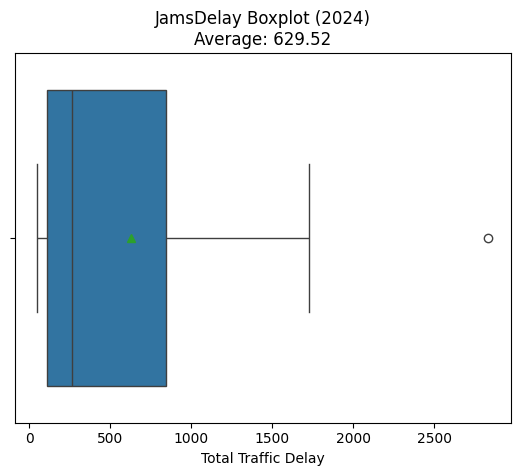

In [88]:
# Create boxplot to observe the behavior of JamsDelay congestion minutes
sns.boxplot(data=merged, x="jams_delay", showmeans=True)

# Get average to show it in the title
mean_value = merged['jams_delay'].mean()
plt.title(f'JamsDelay Boxplot (2024)\nAverage: {mean_value:.2f}')
plt.xlabel('Total Traffic Delay')
plt.show()


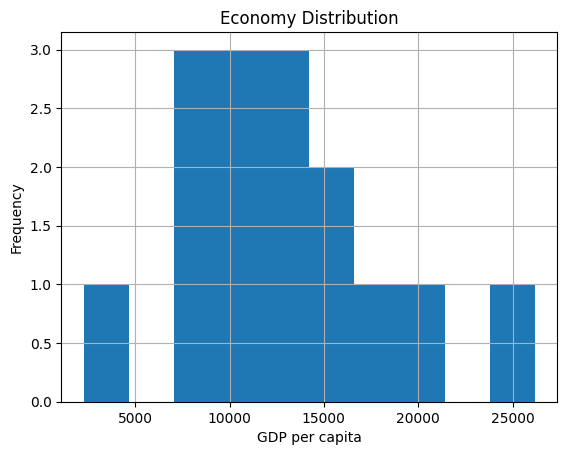

In [89]:
# Create histogram to view the economy distribution (city_gdp_capita)

merged['city_gdp_capita'].hist()
plt.title('Economy Distribution')
plt.xlabel('GDP per capita')
plt.ylabel('Frequency')
plt.show()

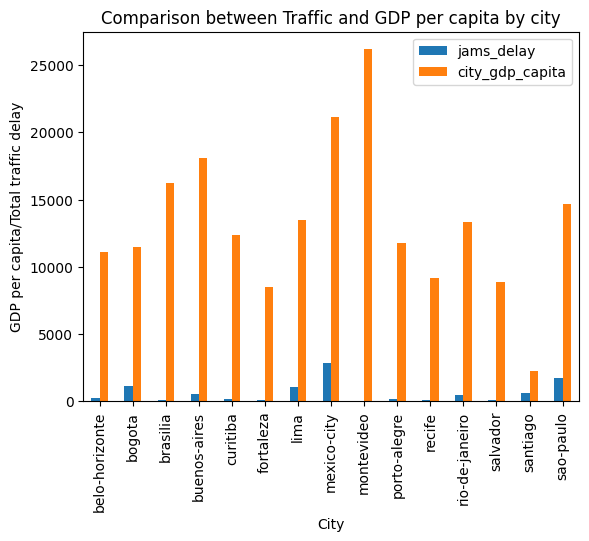

In [90]:
# Bar chart to compare jams_delay and city_gdp_capita by city

merged.plot(kind='bar', x='city', y=['jams_delay', 'city_gdp_capita'])
plt.title('Comparison between Traffic and GDP per capita by city')
plt.ylabel('GDP per capita/Total traffic delay')
plt.xlabel('City')
plt.xticks(rotation=90)
plt.show()

**Key Observation:**
The data does not show a linear correlation between wealth and mobility. For instance, Montevideo exhibits a high GDP per capita coupled with low congestion levels. In contrast, Mexico City, which ranks second in GDP per capita, experiences the highest traffic congestion in the dataset, suggesting that economic productivity does not automatically guarantee efficient urban mobility.


---

## 🧩 Step 7: Exporting & Documentation

The final phase involves consolidating the analytical workflow by exporting the refined dataset and documenting the project's technical outcomes.

### 7.1 Final Dataset Export

**🎯Objective:**
Generate a clean, reproducible, and standardized CSV file containing the key variables identified during the analysis for future modeling or reporting.

**Key Actions**

- Export the `merged` DataFrame to a file named: `ladb_mobility_economy_2024_clean.csv`.

- Set `index=False` to ensure a clean, column-only structure suitable for external tools or database ingestion.

In [87]:
# Export the final dataset as CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

# 🧾 Executive Summary

This summary provides a concise overview of the analytical findings, methodology, and strategic recommendations derived from the urban mobility and economic performance study.

**Context & Strategic Objective:**

The primary objective of this analysis was to evaluate the relationship between urban mobility—specifically congestion and traffic delays—and economic productivity (GDP per capita). However, the findings indicate that there is no clear or consistent correlation between these two variables within the analyzed scope.

**Data Coverage:**

The study focuses on the year 2024, encompassing 15 major Latin American cities across Brazil, Argentina, Colombia, Peru, Mexico, Uruguay, and Chile. The dataset integrates key variables such as traffic congestion, delay times, GDP per capita, unemployment rates, and total population.

**Technical Methodology:**

 The process involved a comprehensive cleaning and standardization of numerical features to ensure format consistency. Data was aggregated at the city-year level and integrated using an Inner Join between mobility and economic indicators. The analytical framework was supported by visual and statistical validations, including distribution reviews, cross-city comparisons, and correlation analysis between congestion levels and GDP per capita.

**Key Findings:**

The results demonstrate that the link between traffic congestion and economic productivity is weak or non-existent. Notable examples include Montevideo, which exhibits low congestion despite a high GDP, and Mexico City, which maintains a high GDP per capita while experiencing the highest congestion levels. This suggests that congestion levels alone are not a definitive driver or indicator of urban economic productivity.

**Strategic Recommendations:**

Investment prioritization cannot be determined solely based on the interplay between congestion and GDP. To enhance the robustness of future insights, it is recommended to:

- **Expand Temporal Scope:** Incorporate multi-year data to identify long-term trends.

- **Feature Enrichment:** Include additional socio-economic or infrastructure variables.

- **Segmented Analysis:** Perform deep dives into city subgroups categorized by similar size and development stages.